# Homework 2 - Regression and Classification: Error Analysis

**Student:** Tedi Revelis<br>
**Student ID:** 313261919<br>
**Dataset:** Hugging Face Models Trending<br>
**Random seed:** 42

This notebook presents a complete regression and classification error analysis using the frozen Hugging Face Models Trending dataset. It combines executable Python, out-of-fold results, visualizations, direct answers, and critical reflection.

## Assignment navigation

1. Data and problem formulation
2. Feature engineering and cross-validation design
3. Regression models and comparison
4. Regression error analysis
5. Classification models and comparison
6. Classification error analysis
7. Integrated discussion
8. Final reflection


## 1. Data and problem formulation

The full CSV contains daily observations of trending Hugging Face models. Repeated daily rows are useful for longitudinal EDA, but they are not independent samples for cross-sectional prediction. I therefore select the **latest snapshot**, which contains exactly 1,000 unique models. This prevents the same model from appearing in both training and validation data and gives each model equal weight.

### Targets

- **Regression target:** `downloads`, the recent download count reported for each model.
- **Classification target:** whether `gated` is `manual` or `auto` rather than `FALSE`. In practical terms, the classifier predicts whether access to a model is restricted.

The classification target is intentionally imbalanced. That makes accuracy alone misleading and motivates precision, recall, F1, MCC, average precision, threshold analysis, and ROC-AUC.


In [1]:
from pathlib import Path
import hashlib
import json
import math
import warnings

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import kurtosis, skew
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.compose import TransformedTargetRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Found unknown categories")
SEED = 42
N_SPLITS = 5
ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "raw" / "hf_models_snapshot.csv"
FIGURE_DIR = ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

def markdown_table(frame, decimals=4):
    "Render a compact GitHub-flavored Markdown table without optional packages."
    formatted = frame.copy()
    for column in formatted.columns:
        if pd.api.types.is_numeric_dtype(formatted[column]):
            formatted[column] = formatted[column].map(
                lambda value: "" if pd.isna(value) else f"{value:,.{decimals}f}"
            )
        else:
            formatted[column] = formatted[column].astype(str)
    header = "| " + " | ".join(map(str, formatted.columns)) + " |"
    divider = "| " + " | ".join(["---"] * len(formatted.columns)) + " |"
    rows = ["| " + " | ".join(row) + " |" for row in formatted.astype(str).itertuples(index=False, name=None)]
    return "\n".join([header, divider, *rows])

raw_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest().upper()
EXPECTED_HASH = "A74C74F76E7FDF3095861AFA3F52484ACE9C1B6EDD83B24B66F87BAA9DDD2966"
assert raw_hash == EXPECTED_HASH, "The raw dataset checksum does not match the documented source file."
raw = pd.read_csv(DATA_PATH, low_memory=False)
assert raw.shape == (156_000, 13)
raw.head(3)


,snapshot_date,id,author,downloads,likes,created_at,last_modified,pipeline_tag,library_name,tags,private,gated,license
0,2/24/2026,sentence-transformers/all-MiniLM-L6-v2,sentence-transformers,171219924,4505,2022-03-02T23:29:05.000Z,2025-03-06T13:37:44.000Z,sentence-similarity,sentence-transformers,sentence-transformers|pytorch|tf|rust|onnx|saf...,False,FALSE,NaN
1,2/24/2026,google-bert/bert-base-uncased,google-bert,54254868,2571,2022-03-02T23:29:04.000Z,2024-02-19T11:06:12.000Z,fill-mask,transformers,transformers|pytorch|tf|jax|rust|coreml|onnx|s...,False,FALSE,NaN
2,2/24/2026,google/electra-base-discriminator,google,43690228,82,2022-03-02T23:29:05.000Z,2024-02-29T10:20:20.000Z,unknown,transformers,transformers|pytorch|tf|jax|rust|electra|pretr...,False,FALSE,NaN


In [2]:
df = raw.copy()
for column in ["snapshot_date", "created_at", "last_modified"]:
    df[column] = pd.to_datetime(df[column], utc=True, errors="coerce")

latest_date = df["snapshot_date"].max()
modeling = df.loc[df["snapshot_date"].eq(latest_date)].copy()
assert len(modeling) == 1_000
assert modeling["id"].is_unique

modeling["model_age_days"] = (
    modeling["snapshot_date"] - modeling["created_at"]
).dt.total_seconds().div(86_400).clip(lower=0)
modeling["days_since_update"] = (
    modeling["snapshot_date"] - modeling["last_modified"]
).dt.total_seconds().div(86_400).clip(lower=0)
modeling["tag_count"] = modeling["tags"].fillna("").str.count(r"\|").add(1)
modeling["library_name"] = modeling["library_name"].fillna("missing")
modeling["gated_status"] = modeling["gated"].replace({"FALSE": "not_gated"})
modeling["is_gated"] = modeling["gated"].ne("FALSE").astype(int)

summary = pd.Series({
    "Full rows": len(df),
    "Full columns": df.shape[1],
    "Snapshot date": latest_date.date().isoformat(),
    "Modeling rows": len(modeling),
    "Unique model IDs": modeling["id"].nunique(),
    "Gated models": int(modeling["is_gated"].sum()),
    "Gated share": modeling["is_gated"].mean(),
    "Dataset SHA-256": raw_hash,
})
summary.to_frame("Value")


,Value
Full rows,156000
Full columns,13
Snapshot date,2026-07-30
Modeling rows,1000
Unique model IDs,1000
Gated models,44
Gated share,0.0440
Dataset SHA-256,A74C74F76E7FDF3095861AFA3F52484ACE9C1B6EDD83B2...


## 2. Feature engineering and cross-validation design

### 2.1 Engineered features

- `model_age_days`: age from creation to the snapshot.
- `days_since_update`: recency of the latest update.
- `tag_count`: a compact measure of metadata richness.
- Missing `library_name` values become an explicit `missing` category rather than being invented by mode imputation.

Identifiers, raw free-text tags, `license` (100% missing), and `private` (constant) are excluded. This avoids identity leakage, uncontrolled dimensionality, and non-informative inputs.

### 2.2 Fair feature sets and classification formulation

Every regression model uses the same seven inputs. Every classification model uses the same six inputs. Preprocessing is fitted inside each fold, so validation rows never influence category encoding, imputation, or scaling.

`downloads` is deliberately excluded from the classification predictors. Gating can itself affect download activity, so contemporaneous downloads may behave as a downstream proxy for the target. The classification task is therefore framed as an error-analysis benchmark using only descriptive metadata. In a production system, the authoritative `gated` field should be read directly whenever it is available rather than replaced by a prediction.


In [3]:
reg_numeric = ["likes", "model_age_days", "days_since_update", "tag_count"]
reg_categorical = ["pipeline_tag", "library_name", "gated_status"]
reg_features = reg_numeric + reg_categorical

clf_numeric = ["likes", "model_age_days", "days_since_update", "tag_count"]
clf_categorical = ["pipeline_tag", "library_name"]
clf_features = clf_numeric + clf_categorical

X_reg = modeling[reg_features]
y_reg = modeling["downloads"].astype(float)
X_clf = modeling[clf_features]
y_clf = modeling["is_gated"].astype(int)

feature_sets = pd.DataFrame({
    "Task": ["Regression", "Classification"],
    "Target": ["downloads", "is_gated"],
    "Numeric features": [", ".join(reg_numeric), ", ".join(clf_numeric)],
    "Categorical features": [", ".join(reg_categorical), ", ".join(clf_categorical)],
})
feature_sets


,Task,Target,Numeric features,Categorical features
0,Regression,downloads,"likes, model_age_days, days_since_update, tag_...","pipeline_tag, library_name, gated_status"
1,Classification,is_gated,"likes, model_age_days, days_since_update, tag_...","pipeline_tag, library_name"


### 2.3 Choice of `k`

I use **5-fold cross-validation**.

- With 1,000 independent model rows, each regression fold validates on about 200 rows and trains on about 800.
- There are 44 gated models. Stratified 5-fold classification preserves about 8-9 positives per validation fold; 10-fold CV would leave only 4-5 positives per fold and make error estimates less stable.
- Five folds provide a practical bias-variance compromise: substantially less split dependence than a single holdout, while keeping four regression and three classification models computationally affordable.
- Regression uses shuffled `KFold`; classification uses shuffled `StratifiedKFold` because of class imbalance.

The model settings below are fixed, regularized configurations chosen before evaluation; they are not tuned on the reported out-of-fold scores. The preprocessing pipeline is refitted separately inside every fold. All reported predictions below are **out-of-fold predictions**, meaning each observation is predicted only by a model that did not train on it.


In [4]:
def make_preprocessor(numeric, categorical, scale=True):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_pipe = Pipeline(numeric_steps)
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=5,
            drop="first",
            sparse_output=True,
        )),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipe, numeric),
        ("categorical", categorical_pipe, categorical),
    ])


def regression_pipeline(regressor, scale=True):
    base = Pipeline([
        ("preprocess", make_preprocessor(reg_numeric, reg_categorical, scale=scale)),
        ("model", regressor),
    ])
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=True,
    )


reg_models = {
    "Linear Regression": regression_pipeline(LinearRegression(), scale=True),
    "Decision Tree": regression_pipeline(
        DecisionTreeRegressor(max_depth=10, min_samples_leaf=8, random_state=SEED),
        scale=False,
    ),
    "Random Forest": regression_pipeline(
        RandomForestRegressor(
            n_estimators=180,
            max_depth=16,
            min_samples_leaf=3,
            max_features=0.75,
            n_jobs=-1,
            random_state=SEED,
        ),
        scale=False,
    ),
    "KNN (bonus)": regression_pipeline(
        KNeighborsRegressor(n_neighbors=15, weights="distance", p=2),
        scale=True,
    ),
}

reg_hyperparameters = pd.DataFrame({
    "Model": list(reg_models),
    "Key settings": [
        "log1p target; scaled numeric inputs; ordinary least squares",
        "max_depth=10; min_samples_leaf=8; log1p target",
        "180 trees; max_depth=16; min_samples_leaf=3; max_features=0.75; log1p target",
        "n_neighbors=15; distance weights; scaled inputs; log1p target",
    ],
})
reg_hyperparameters


,Model,Key settings
0,Linear Regression,log1p target; scaled numeric inputs; ordinary ...
1,Decision Tree,max_depth=10; min_samples_leaf=8; log1p target
2,Random Forest,180 trees; max_depth=16; min_samples_leaf=3; m...
3,KNN (bonus),n_neighbors=15; distance weights; scaled input...


## 3. Regression models and comparison

Downloads are extremely right-skewed. All four regressors therefore learn `log1p(downloads)` through `TransformedTargetRegressor`, then automatically transform predictions back to the original download scale. This reduces domination by a few huge models while preserving interpretable residuals and metrics in actual downloads.

The required models are Linear Regression, Decision Tree Regressor, and an ensemble Random Forest Regressor. KNN is included as the optional bonus model.


In [5]:
def regression_oof(models, X, y, cv):
    predictions = {}
    fold_rows = []
    for name, estimator in models.items():
        oof = np.full(len(y), np.nan, dtype=float)
        for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
            fitted = clone(estimator).fit(X.iloc[train_idx], y.iloc[train_idx])
            fold_pred = np.maximum(fitted.predict(X.iloc[test_idx]), 0)
            oof[test_idx] = fold_pred
            fold_rows.append({
                "Model": name,
                "Fold": fold,
                "MAE": mean_absolute_error(y.iloc[test_idx], fold_pred),
                "MSE": mean_squared_error(y.iloc[test_idx], fold_pred),
                "RMSE": math.sqrt(mean_squared_error(y.iloc[test_idx], fold_pred)),
                "R2": r2_score(y.iloc[test_idx], fold_pred),
            })
        assert not np.isnan(oof).any()
        predictions[name] = oof
    return predictions, pd.DataFrame(fold_rows)


reg_cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
reg_predictions, reg_fold_metrics = regression_oof(reg_models, X_reg, y_reg, reg_cv)

reg_metrics = []
for name, pred in reg_predictions.items():
    reg_metrics.append({
        "Model": name,
        "MAE": mean_absolute_error(y_reg, pred),
        "MSE": mean_squared_error(y_reg, pred),
        "RMSE": math.sqrt(mean_squared_error(y_reg, pred)),
        "R2": r2_score(y_reg, pred),
        "Fold RMSE SD": reg_fold_metrics.loc[reg_fold_metrics["Model"].eq(name), "RMSE"].std(),
    })
reg_metrics = pd.DataFrame(reg_metrics).sort_values("RMSE").reset_index(drop=True)
preferred_reg_name = reg_metrics.iloc[0]["Model"]
preferred_reg_pred = reg_predictions[preferred_reg_name]
reg_metrics


,Model,MAE,MSE,RMSE,R2,Fold RMSE SD
0,Random Forest,"1,873,999.9833","94,809,189,863,379.2812","9,737,001.0713",0.0755,"7,263,313.5518"
1,Decision Tree,"2,057,339.2277","97,132,917,570,062.0312","9,855,603.3590",0.0529,"7,236,446.9667"
2,KNN (bonus),"1,960,761.2634","101,894,913,683,865.6250","10,094,301.0498",0.0064,"7,463,382.6748"
3,Linear Regression,"2,567,832.7874","388,645,134,205,866.7500","19,714,084.6657",-2.7897,"15,891,607.5161"


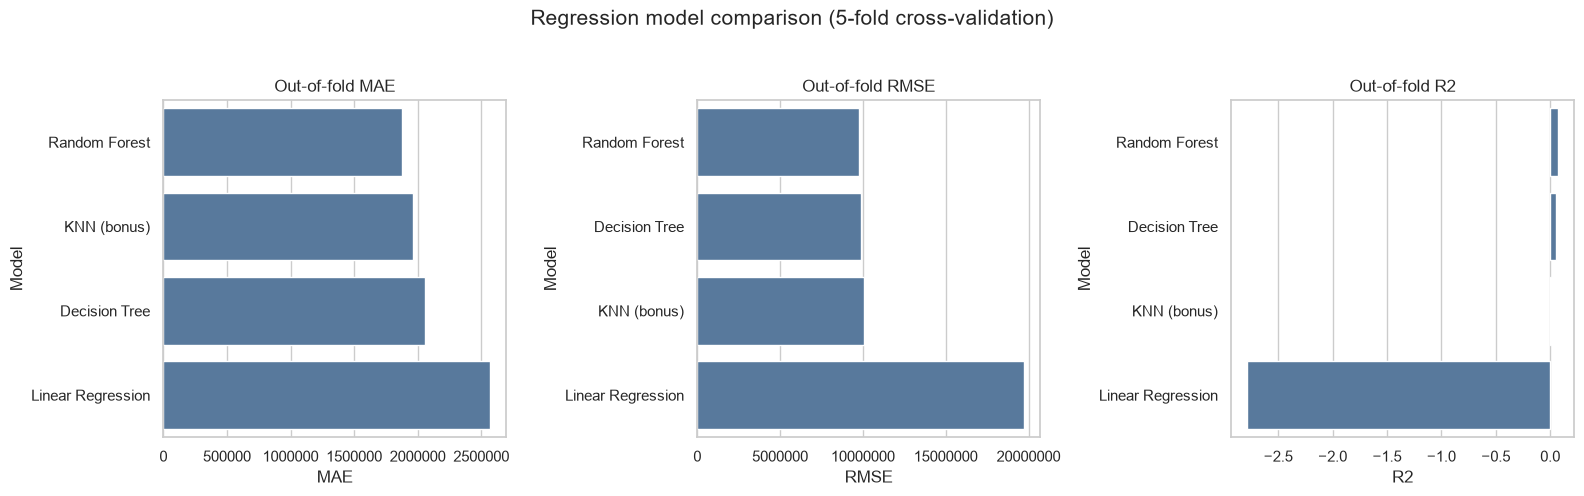

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
plot_metrics = ["MAE", "RMSE", "R2"]
for ax, metric in zip(axes, plot_metrics):
    order = reg_metrics.sort_values(metric, ascending=metric != "R2")
    sns.barplot(data=order, x=metric, y="Model", ax=ax, color="#4C78A8")
    ax.set_title(f"Out-of-fold {metric}")
    if metric != "R2":
        ax.ticklabel_format(style="plain", axis="x")
fig.suptitle("Regression model comparison (5-fold cross-validation)", fontsize=15, y=1.03)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_regression_model_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


In [7]:
best_reg = reg_metrics.iloc[0]
worst_reg = reg_metrics.sort_values("RMSE", ascending=False).iloc[0]
display(Markdown(f'''
### 3.3 Regression interpretation

**Preferred model:** **{preferred_reg_name}**, because it achieved the lowest out-of-fold RMSE ({best_reg['RMSE']:,.0f}) and MAE ({best_reg['MAE']:,.0f}), with R2 = {best_reg['R2']:.3f}.

- **Relative performance:** nonlinear models can capture thresholds and interactions among likes, age, recency, task, and library. The linear baseline is more interpretable but imposes additive linear effects after encoding.
- **Assumptions:** independence is supported by using one row per model. Normality and homoskedasticity are not expected on the raw download scale; the log target reduces, but does not eliminate, heavy tails.
- **Bias-variance:** the linear model has higher structural bias. A single tree can have high variance; depth and leaf-size limits regularize it. Random Forest averages many trees and generally reduces variance. KNN is local and can be unstable in sparse or rare regions.
- **Outliers and noise:** raw download extremes strongly affect squared-error metrics. Log-target fitting reduces their training influence, while original-scale evaluation keeps their practical cost visible.
- **Interpretability versus performance:** Linear Regression is easiest to explain and a single tree is inspectable, while Random Forest usually offers stronger predictive performance at the cost of less transparent decisions.
- **What I learned:** popularity is not described by one global linear rule. Large models, niche tasks, and recently updated models can behave differently, and the low aggregate R2 confirms that error analysis is essential.
'''))



### 3.3 Regression interpretation

**Preferred model:** **Random Forest**, because it achieved the lowest out-of-fold RMSE (9,737,001) and MAE (1,874,000), with R2 = 0.076.

- **Relative performance:** nonlinear models can capture thresholds and interactions among likes, age, recency, task, and library. The linear baseline is more interpretable but imposes additive linear effects after encoding.
- **Assumptions:** independence is supported by using one row per model. Normality and homoskedasticity are not expected on the raw download scale; the log target reduces, but does not eliminate, heavy tails.
- **Bias-variance:** the linear model has higher structural bias. A single tree can have high variance; depth and leaf-size limits regularize it. Random Forest averages many trees and generally reduces variance. KNN is local and can be unstable in sparse or rare regions.
- **Outliers and noise:** raw download extremes strongly affect squared-error metrics. Log-target fitting reduces their training influence, while original-scale evaluation keeps their practical cost visible.
- **Interpretability versus performance:** Linear Regression is easiest to explain and a single tree is inspectable, while Random Forest usually offers stronger predictive performance at the cost of less transparent decisions.
- **What I learned:** popularity is not described by one global linear rule. Large models, niche tasks, and recently updated models can behave differently, and the low aggregate R2 confirms that error analysis is essential.


## 4. Regression error analysis

All residual analyses use out-of-fold predictions from the preferred regression model. The residual is defined exactly as required:

\[
e_i = y_i - \hat{y}_i
\]

Positive residuals are under-predictions; negative residuals are over-predictions.


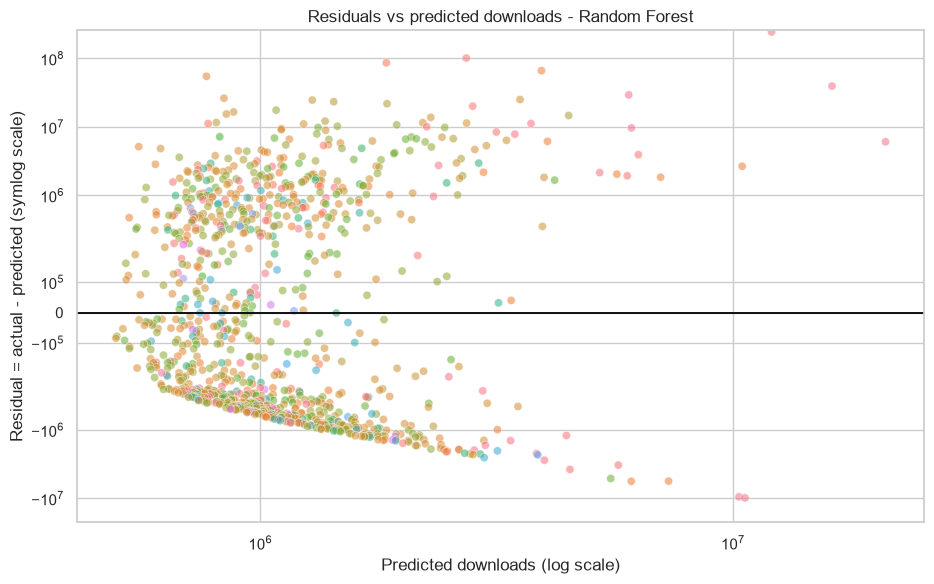

In [8]:
reg_errors = modeling[["id", "author", "pipeline_tag", "library_name", "gated_status"] + reg_numeric].copy()
reg_errors["actual"] = y_reg.to_numpy()
reg_errors["predicted"] = preferred_reg_pred
reg_errors["residual"] = reg_errors["actual"] - reg_errors["predicted"]
reg_errors["absolute_error"] = reg_errors["residual"].abs()
reg_errors["absolute_percentage_error"] = reg_errors["absolute_error"] / reg_errors["actual"].clip(lower=1)

fig, ax = plt.subplots(figsize=(9.5, 6))
sns.scatterplot(data=reg_errors, x="predicted", y="residual", hue="pipeline_tag", legend=False, alpha=.55, s=35, ax=ax)
ax.axhline(0, color="black", linewidth=1.3)
ax.set_xscale("log")
ax.set_yscale("symlog", linthresh=250_000)
ax.set_title(f"Residuals vs predicted downloads - {preferred_reg_name}")
ax.set_xlabel("Predicted downloads (log scale)")
ax.set_ylabel("Residual = actual - predicted (symlog scale)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_residuals_vs_predicted.png", dpi=180, bbox_inches="tight")
plt.show()


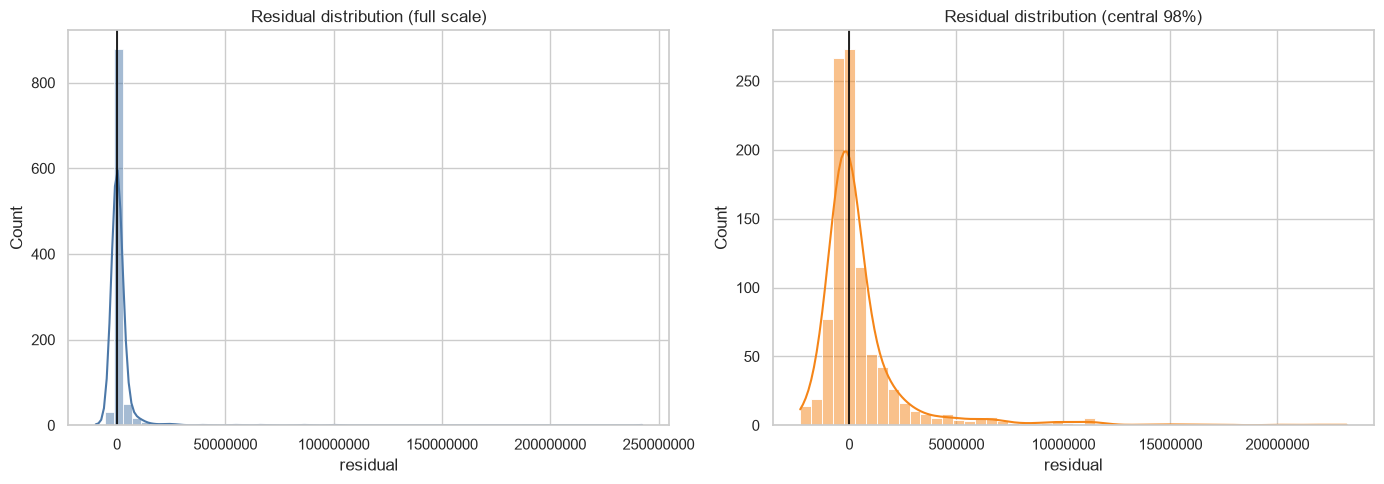


### 4.1-4.2 Direct answers

- **Centered around zero?** The mean residual is 1,222,514 and the median is -95,890. The median is the more robust center because a few very large models dominate the mean.
- **Systematic patterns?** The residual cloud widens as predicted downloads increase and contains several large positive residuals, showing systematic under-prediction of exceptional blockbusters.
- **Heteroscedasticity?** Yes. Mean absolute error rises from 791,304 in the lower predicted half to 2,956,696 in the upper half. Error variance is not constant.


In [9]:
residual_mean = reg_errors["residual"].mean()
residual_median = reg_errors["residual"].median()
low_pred_mae = reg_errors.loc[reg_errors["predicted"].le(reg_errors["predicted"].median()), "absolute_error"].mean()
high_pred_mae = reg_errors.loc[reg_errors["predicted"].gt(reg_errors["predicted"].median()), "absolute_error"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(reg_errors["residual"], bins=60, kde=True, ax=axes[0], color="#4C78A8")
axes[0].axvline(0, color="black", linewidth=1.2)
axes[0].set_title("Residual distribution (full scale)")
axes[0].ticklabel_format(style="plain", axis="x")
trim = reg_errors["residual"].between(reg_errors["residual"].quantile(.01), reg_errors["residual"].quantile(.99))
sns.histplot(reg_errors.loc[trim, "residual"], bins=50, kde=True, ax=axes[1], color="#F58518")
axes[1].axvline(0, color="black", linewidth=1.2)
axes[1].set_title("Residual distribution (central 98%)")
axes[1].ticklabel_format(style="plain", axis="x")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_residual_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

display(Markdown(f'''
### 4.1-4.2 Direct answers

- **Centered around zero?** The mean residual is {residual_mean:,.0f} and the median is {residual_median:,.0f}. The median is the more robust center because a few very large models dominate the mean.
- **Systematic patterns?** The residual cloud widens as predicted downloads increase and contains several large positive residuals, showing systematic under-prediction of exceptional blockbusters.
- **Heteroscedasticity?** Yes. Mean absolute error rises from {low_pred_mae:,.0f} in the lower predicted half to {high_pred_mae:,.0f} in the upper half. Error variance is not constant.
'''))


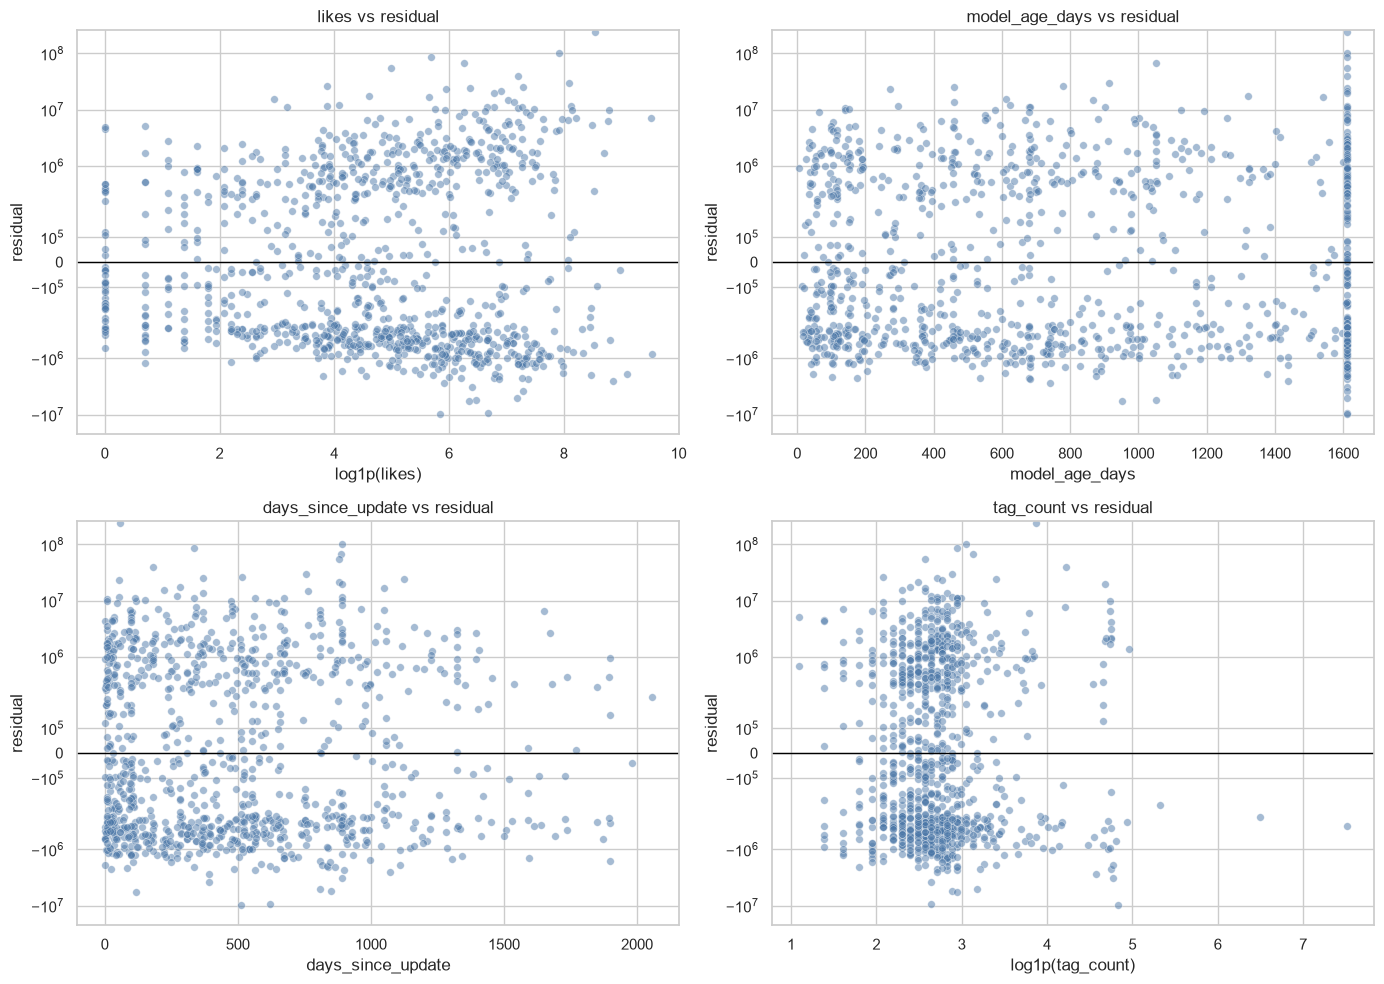

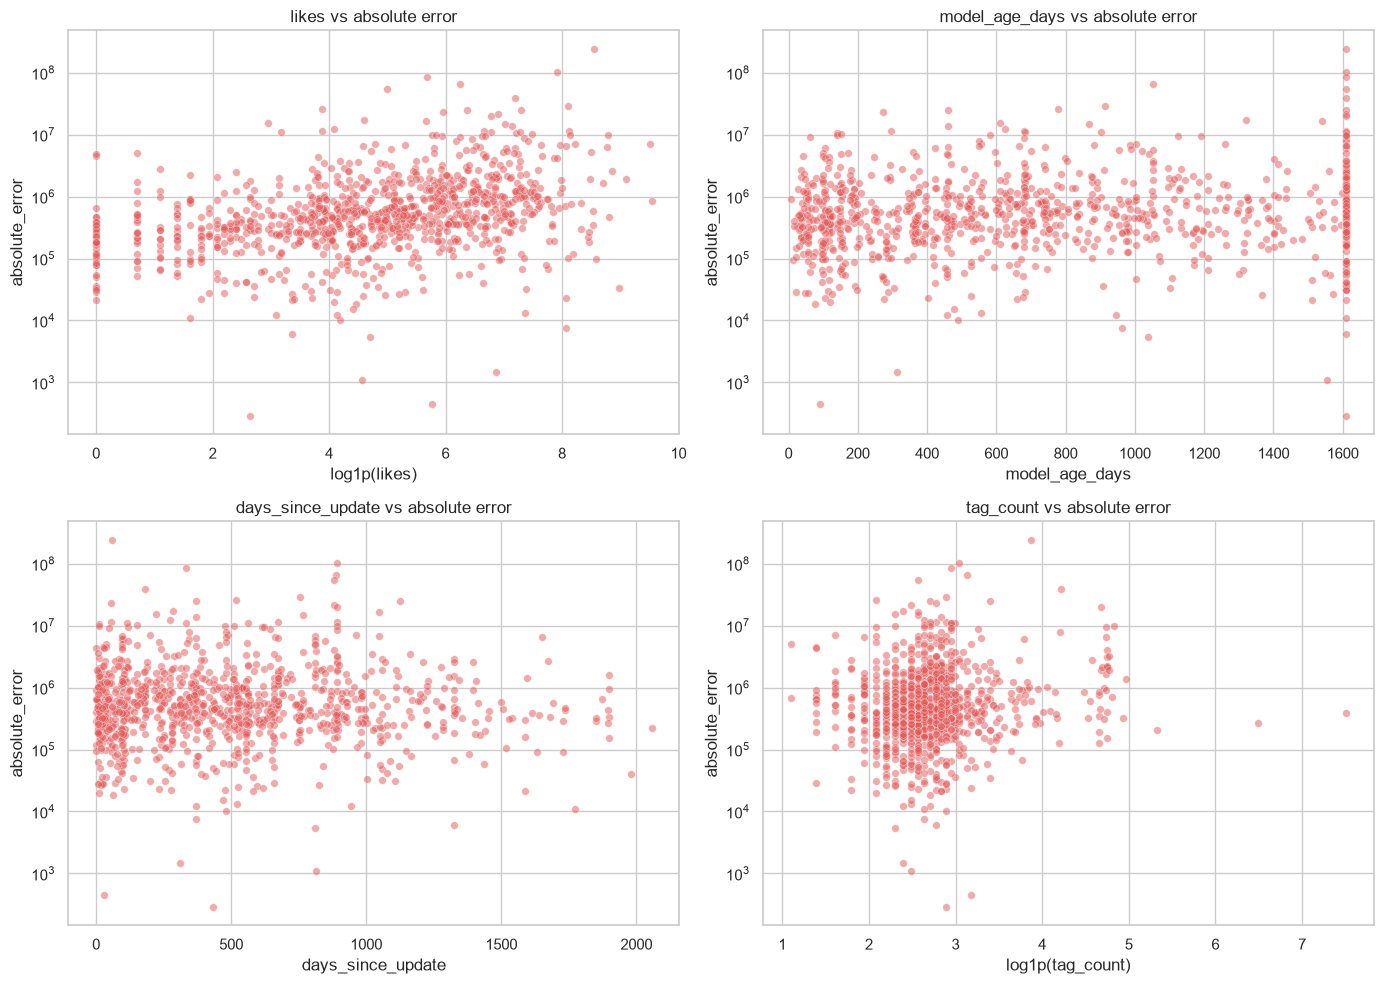

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feature in zip(axes.ravel(), reg_numeric):
    plot_frame = reg_errors.copy()
    x_column = feature
    if feature in {"likes", "tag_count"}:
        x_column = f"log1p_{feature}"
        plot_frame[x_column] = np.log1p(plot_frame[feature])
    sns.scatterplot(data=plot_frame, x=x_column, y="residual", alpha=.5, s=30, ax=ax, color="#4C78A8")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_yscale("symlog", linthresh=250_000)
    ax.set_xlabel(f"log1p({feature})" if x_column != feature else feature)
    ax.set_title(f"{feature} vs residual")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_residuals_by_numeric_features.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feature in zip(axes.ravel(), reg_numeric):
    plot_frame = reg_errors.copy()
    x_column = feature
    if feature in {"likes", "tag_count"}:
        x_column = f"log1p_{feature}"
        plot_frame[x_column] = np.log1p(plot_frame[feature])
    sns.scatterplot(data=plot_frame, x=x_column, y="absolute_error", alpha=.5, s=30, ax=ax, color="#E45756")
    ax.set_yscale("log")
    ax.set_xlabel(f"log1p({feature})" if x_column != feature else feature)
    ax.set_title(f"{feature} vs absolute error")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_absolute_error_by_numeric_features.png", dpi=180, bbox_inches="tight")
plt.show()


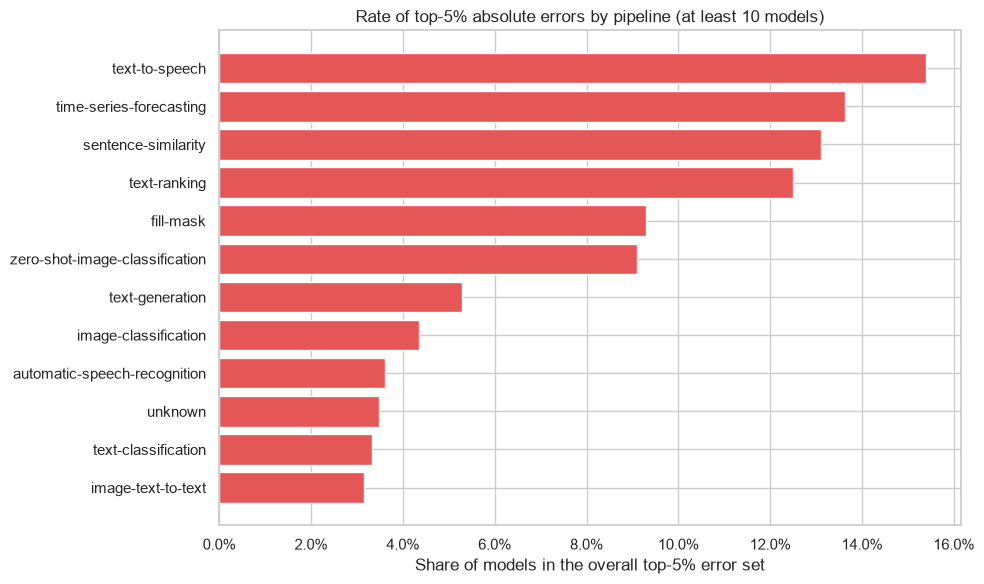

,models,high_error_count,high_error_rate,MAE,median_AE
pipeline_tag,,,,,
text-to-speech,13,2,0.1538,"1,927,924.5332","827,817.7804"
time-series-forecasting,22,3,0.1364,"2,858,370.9806","887,480.0521"
sentence-similarity,61,8,0.1311,"6,592,400.9423","529,752.4463"
text-ranking,16,2,0.1250,"6,862,056.1358","812,106.5712"
fill-mask,43,4,0.0930,"4,229,700.7325","485,065.1665"
zero-shot-image-classification,22,2,0.0909,"2,012,881.6160","573,263.8087"
text-generation,227,12,0.0529,"1,327,565.3730","454,378.1365"
image-classification,23,1,0.0435,"1,651,078.4652","415,038.8159"
automatic-speech-recognition,83,3,0.0361,"877,135.0408","366,482.4602"


In [11]:
n_extreme = math.ceil(0.05 * len(reg_errors))
extreme_indices = reg_errors.nlargest(n_extreme, "absolute_error").index
reg_errors["is_extreme"] = reg_errors.index.isin(extreme_indices)
extreme_cutoff = reg_errors.loc[extreme_indices, "absolute_error"].min()

pipeline_error = (
    reg_errors.groupby("pipeline_tag", observed=True)
    .agg(
        models=("id", "size"),
        high_error_count=("is_extreme", "sum"),
        high_error_rate=("is_extreme", "mean"),
        MAE=("absolute_error", "mean"),
        median_AE=("absolute_error", "median"),
    )
    .query("models >= 10")
    .sort_values(["high_error_rate", "MAE"], ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_pipeline_error = pipeline_error.head(12).sort_values(["high_error_rate", "MAE"])
ax.barh(top_pipeline_error.index, top_pipeline_error["high_error_rate"], color="#E45756")
ax.set_title("Rate of top-5% absolute errors by pipeline (at least 10 models)")
ax.set_xlabel("Share of models in the overall top-5% error set")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
fig.tight_layout()
fig.savefig(FIGURE_DIR / "06_extreme_errors_by_pipeline.png", dpi=180, bbox_inches="tight")
plt.show()

pipeline_error.head(12)


In [12]:
extreme = reg_errors.loc[extreme_indices].copy().sort_values("absolute_error", ascending=False)
pipeline_counts = modeling["pipeline_tag"].value_counts()
download_median = modeling["downloads"].median()
download_p99 = modeling["downloads"].quantile(.99)


def diagnose_extreme(row):
    factors = []
    if row["actual"] >= download_p99:
        factors.append("blockbuster above the 99th download percentile")
    if pipeline_counts[row["pipeline_tag"]] < 10:
        factors.append("rare pipeline with fewer than 10 models")
    if row["library_name"] == "missing":
        factors.append("missing library metadata")
    if not factors:
        factors.append("available features do not explain this observation's scale")
    return "; ".join(factors)


extreme["likely_source"] = extreme.apply(diagnose_extreme, axis=1)
extreme["error_direction"] = np.where(extreme["residual"].ge(0), "under-prediction", "over-prediction")
extreme["pipeline_models"] = extreme["pipeline_tag"].map(pipeline_counts)
extreme["actual_to_median"] = extreme["actual"] / max(download_median, 1)
extreme["individual_note"] = extreme.apply(
    lambda row: (
        f"{row['error_direction'].capitalize()} by {row['absolute_error']:,.0f} downloads; "
        f"actual downloads are {row['actual_to_median']:.1f}x the snapshot median; "
        f"pipeline '{row['pipeline_tag']}' contains {int(row['pipeline_models'])} models; "
        f"evidence points to {row['likely_source']}."
    ),
    axis=1,
)
assert len(extreme) == n_extreme == 50

extreme_individual = extreme[[
    "id", "pipeline_tag", "library_name", "actual", "predicted", "residual",
    "absolute_error", "error_direction", "pipeline_models", "actual_to_median",
    "likely_source", "individual_note",
]]
extreme_individual.to_csv(
    ROOT / "reports" / "EXTREME_ERROR_ANALYSIS.csv",
    index=False,
    lineterminator="\n",
)
extreme_individual

,id,pipeline_tag,library_name,actual,predicted,residual,absolute_error,error_direction,pipeline_models,actual_to_median,likely_source,individual_note
155000,sentence-transformers/all-MiniLM-L6-v2,sentence-similarity,sentence-transformers,"254,507,269.0000","12,063,892.9501","242,443,376.0499","242,443,376.0499",under-prediction,61,291.8871,blockbuster above the 99th download percentile,"Under-prediction by 242,443,376 downloads; act..."
155001,google-bert/bert-base-uncased,fill-mask,transformers,"103,531,008.0000","2,726,865.6792","100,804,142.3208","100,804,142.3208",under-prediction,43,118.7367,blockbuster above the 99th download percentile,"Under-prediction by 100,804,142 downloads; act..."
155002,cross-encoder/ms-marco-MiniLM-L6-v2,text-ranking,sentence-transformers,"87,928,707.0000","1,847,309.4624","86,081,397.5376","86,081,397.5376",under-prediction,16,100.8429,blockbuster above the 99th download percentile,"Under-prediction by 86,081,398 downloads; actu..."
155003,BAAI/bge-small-en-v1.5,feature-extraction,sentence-transformers,"70,010,908.0000","3,933,840.7465","66,077,067.2535","66,077,067.2535",under-prediction,51,80.2935,blockbuster above the 99th download percentile,"Under-prediction by 66,077,067 downloads; actu..."
155005,google/electra-base-discriminator,unknown,transformers,"55,418,883.0000","769,127.5859","54,649,755.4141","54,649,755.4141",under-prediction,115,63.5583,blockbuster above the 99th download percentile,"Under-prediction by 54,649,755 downloads; actu..."
155004,sentence-transformers/paraphrase-multilingual-...,sentence-similarity,sentence-transformers,"55,559,128.0000","16,201,320.2176","39,357,807.7824","39,357,807.7824",under-prediction,61,63.7192,blockbuster above the 99th download percentile,"Under-prediction by 39,357,808 downloads; actu..."
155006,BAAI/bge-m3,sentence-similarity,sentence-transformers,"35,229,091.0000","6,017,507.7626","29,211,583.2374","29,211,583.2374",under-prediction,61,40.4032,blockbuster above the 99th download percentile,"Under-prediction by 29,211,583 downloads; actu..."
155009,lpiccinelli/unidepth-v2-vitl14,unknown,UniDepth,"27,002,738.0000","837,359.1460","26,165,378.8540","26,165,378.8540",under-prediction,115,30.9687,blockbuster above the 99th download percentile,"Under-prediction by 26,165,379 downloads; actu..."
155007,Qwen/Qwen3-0.6B,text-generation,transformers,"28,544,146.0000","3,543,279.1183","25,000,866.8817","25,000,866.8817",under-prediction,227,32.7365,blockbuster above the 99th download percentile,"Under-prediction by 25,000,867 downloads; actu..."
155010,google-t5/t5-small,translation,transformers,"25,837,868.0000","1,287,777.5113","24,550,090.4887","24,550,090.4887",under-prediction,9,29.6327,rare pipeline with fewer than 10 models,"Under-prediction by 24,550,090 downloads; actu..."


In [13]:
error_stats = pd.Series({
    "MAE": mean_absolute_error(reg_errors["actual"], reg_errors["predicted"]),
    "Residual mean": reg_errors["residual"].mean(),
    "Residual standard deviation": reg_errors["residual"].std(ddof=1),
    "Residual skewness": skew(reg_errors["residual"], bias=False),
    "Residual excess kurtosis": kurtosis(reg_errors["residual"], fisher=True, bias=False),
    "Top-5% absolute-error cutoff": extreme_cutoff,
})
error_stats.to_frame("Value")

,Value
MAE,"1,873,999.9833"
Residual mean,"1,222,514.2383"
Residual standard deviation,"9,664,784.3668"
Residual skewness,18.0317
Residual excess kurtosis,408.6291
Top-5% absolute-error cutoff,"6,201,935.7098"


In [14]:
highest_sector = pipeline_error.index[0]
highest_sector_rate = pipeline_error.iloc[0]["high_error_rate"]
highest_sector_count = int(pipeline_error.iloc[0]["high_error_count"])
highest_sector_models = int(pipeline_error.iloc[0]["models"])
display(Markdown(f'''
### 4.3-4.5 Regression error interpretation

- **Feature-dependent patterns:** absolute error generally increases with `likes`, which is a proxy for scale. Age and update recency show overlapping subpopulations rather than a single clean linear relationship.
- **High-error sector:** among sectors with at least 10 models, `{highest_sector}` has the largest observed rate of top-5% errors: {highest_sector_count} of {highest_sector_models} models ({highest_sector_rate:.1%}). The rate, rather than mean error alone, directly answers which sector is more likely to contain a high-error case. The small group size is reported to avoid overstating certainty.
- **Top 5%:** the 50 observations with the largest absolute errors are displayed individually above and exported to `reports/EXTREME_ERROR_ANALYSIS.csv`. Each row reports the direction and size of the error, its scale relative to the dataset median, local pipeline sample size, and an evidence-based likely-source note.
- **Data quality:** missing library metadata can remove useful technical context; it is preserved as `missing` rather than silently imputed.
- **Model limitations:** every model lacks external events, deployment integrations, marketing, and API traffic. These omissions are especially costly for exceptional models.
- **Rare cases:** the largest download counts and rare pipeline categories lie in sparsely represented feature regions.
- **Heavy tails:** residual skewness is {error_stats['Residual skewness']:.2f}; excess kurtosis is {error_stats['Residual excess kurtosis']:.2f}. The large positive values indicate a heavy right tail and instability caused by exceptional under-predictions.
'''))



### 4.3-4.5 Regression error interpretation

- **Feature-dependent patterns:** absolute error generally increases with `likes`, which is a proxy for scale. Age and update recency show overlapping subpopulations rather than a single clean linear relationship.
- **High-error sector:** among sectors with at least 10 models, `text-to-speech` has the largest observed rate of top-5% errors: 2 of 13 models (15.4%). The rate, rather than mean error alone, directly answers which sector is more likely to contain a high-error case. The small group size is reported to avoid overstating certainty.
- **Top 5%:** the 50 observations with the largest absolute errors are displayed individually above and exported to `reports/EXTREME_ERROR_ANALYSIS.csv`. Each row reports the direction and size of the error, its scale relative to the dataset median, local pipeline sample size, and an evidence-based likely-source note.
- **Data quality:** missing library metadata can remove useful technical context; it is preserved as `missing` rather than silently imputed.
- **Model limitations:** every model lacks external events, deployment integrations, marketing, and API traffic. These omissions are especially costly for exceptional models.
- **Rare cases:** the largest download counts and rare pipeline categories lie in sparsely represented feature regions.
- **Heavy tails:** residual skewness is 18.03; excess kurtosis is 408.63. The large positive values indicate a heavy right tail and instability caused by exceptional under-predictions.


## 5. Classification models and comparison

The classification task predicts whether a model is gated. Three models are compared on the same six descriptive metadata features:

1. Logistic Regression - interpretable linear probability baseline.
2. Decision Tree Classifier - nonlinear rules and interactions.
3. Random Forest Classifier - ensemble intended to reduce tree variance.

All models use balanced class weights because only 44 of 1,000 latest-snapshot models are gated. Stratified folds preserve this minority class in every validation fold. `downloads` is excluded because gating may itself affect downloads; in a live system, the authoritative gated-status field should be used directly whenever available.


In [15]:
def classification_pipeline(classifier, scale=True):
    return Pipeline([
        ("preprocess", make_preprocessor(clf_numeric, clf_categorical, scale=scale)),
        ("model", classifier),
    ])


clf_models = {
    "Logistic Regression": classification_pipeline(
        LogisticRegression(C=1.0, class_weight="balanced", max_iter=3_000, random_state=SEED),
        scale=True,
    ),
    "Decision Tree": classification_pipeline(
        DecisionTreeClassifier(max_depth=8, min_samples_leaf=6, class_weight="balanced", random_state=SEED),
        scale=False,
    ),
    "Random Forest": classification_pipeline(
        RandomForestClassifier(
            n_estimators=240,
            max_depth=14,
            min_samples_leaf=3,
            max_features=0.75,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED,
        ),
        scale=False,
    ),
}

clf_hyperparameters = pd.DataFrame({
    "Model": list(clf_models),
    "Key settings": [
        "C=1; class_weight=balanced; max_iter=3000",
        "max_depth=8; min_samples_leaf=6; class_weight=balanced",
        "240 trees; max_depth=14; min_samples_leaf=3; class_weight=balanced_subsample",
    ],
})
clf_hyperparameters


,Model,Key settings
0,Logistic Regression,C=1; class_weight=balanced; max_iter=3000
1,Decision Tree,max_depth=8; min_samples_leaf=6; class_weight=...
2,Random Forest,240 trees; max_depth=14; min_samples_leaf=3; c...


In [16]:
def classification_oof(models, X, y, cv):
    probabilities = {}
    fold_rows = []
    for name, estimator in models.items():
        oof = np.full(len(y), np.nan, dtype=float)
        for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
            fitted = clone(estimator).fit(X.iloc[train_idx], y.iloc[train_idx])
            fold_prob = fitted.predict_proba(X.iloc[test_idx])[:, 1]
            oof[test_idx] = fold_prob
            fold_pred = (fold_prob >= .5).astype(int)
            fold_rows.append({
                "Model": name,
                "Fold": fold,
                "ROC-AUC": roc_auc_score(y.iloc[test_idx], fold_prob),
                "Average Precision": average_precision_score(y.iloc[test_idx], fold_prob),
                "F1": f1_score(y.iloc[test_idx], fold_pred, zero_division=0),
                "MCC": matthews_corrcoef(y.iloc[test_idx], fold_pred),
            })
        assert not np.isnan(oof).any()
        probabilities[name] = oof
    return probabilities, pd.DataFrame(fold_rows)


clf_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
clf_probabilities, clf_fold_metrics = classification_oof(clf_models, X_clf, y_clf, clf_cv)

clf_metrics = []
for name, prob in clf_probabilities.items():
    pred = (prob >= .5).astype(int)
    clf_metrics.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_clf, prob),
        "Average Precision": average_precision_score(y_clf, prob),
        "Precision@0.5": precision_score(y_clf, pred, zero_division=0),
        "Recall@0.5": recall_score(y_clf, pred, zero_division=0),
        "F1@0.5": f1_score(y_clf, pred, zero_division=0),
        "MCC@0.5": matthews_corrcoef(y_clf, pred),
        "Balanced Accuracy@0.5": balanced_accuracy_score(y_clf, pred),
        "Fold AUC SD": clf_fold_metrics.loc[clf_fold_metrics["Model"].eq(name), "ROC-AUC"].std(),
    })
clf_metrics = pd.DataFrame(clf_metrics).sort_values(["Average Precision", "ROC-AUC"], ascending=False).reset_index(drop=True)
preferred_clf_name = clf_metrics.iloc[0]["Model"]
preferred_clf_prob = clf_probabilities[preferred_clf_name]
clf_metrics


,Model,ROC-AUC,Average Precision,Precision@0.5,Recall@0.5,F1@0.5,MCC@0.5,Balanced Accuracy@0.5,Fold AUC SD
0,Random Forest,0.8849,0.5938,0.7143,0.4545,0.5556,0.5547,0.7231,0.0719
1,Decision Tree,0.7577,0.3685,0.1884,0.5909,0.2857,0.2817,0.7369,0.0432
2,Logistic Regression,0.8320,0.2644,0.1921,0.7727,0.3077,0.3349,0.8116,0.0898


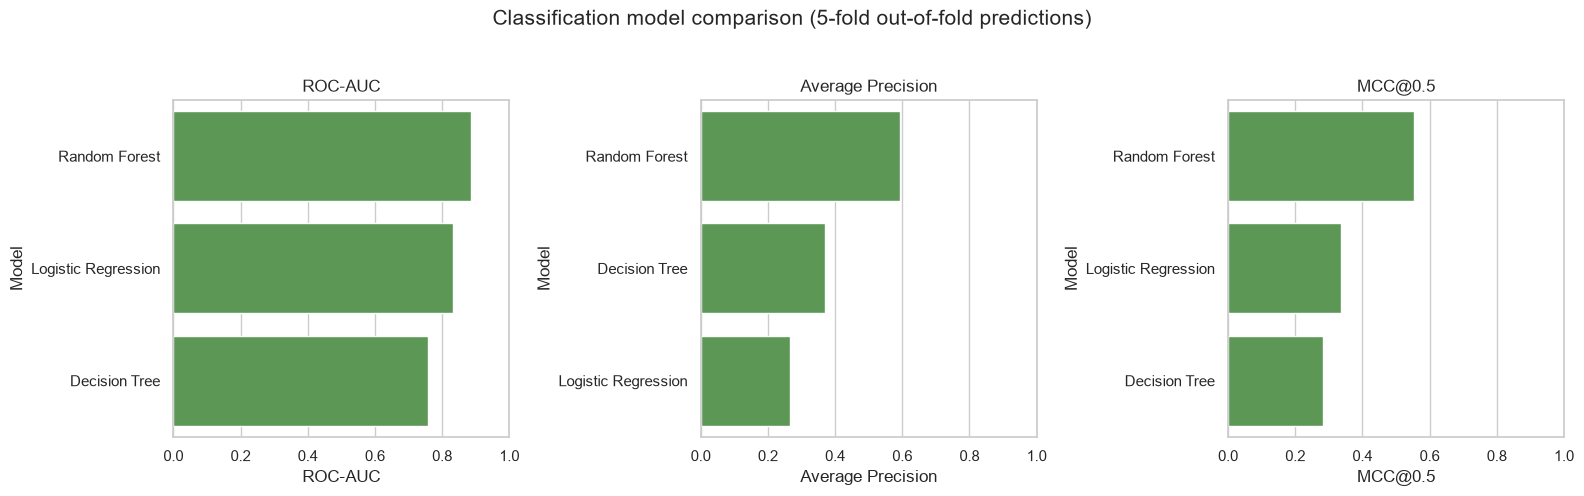


### 5.3 Classification comparison

**Preferred model:** **Random Forest**. It has the strongest minority-class ranking performance by average precision (0.594) and ROC-AUC (0.885). Accuracy is deliberately not used for selection because predicting every model as not gated would already be 95.6% accurate.

Logistic Regression is the most interpretable but assumes additive effects in log-odds. A single tree captures thresholds and interactions but can change sharply with the sample. Random Forest reduces that variance, though it is less transparent and its probabilities still require threshold selection.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, metric in zip(axes, ["ROC-AUC", "Average Precision", "MCC@0.5"]):
    order = clf_metrics.sort_values(metric, ascending=False)
    sns.barplot(data=order, x=metric, y="Model", ax=ax, color="#54A24B")
    ax.set_xlim(min(0, order[metric].min() - .1), 1)
    ax.set_title(metric)
fig.suptitle("Classification model comparison (5-fold out-of-fold predictions)", fontsize=15, y=1.03)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "07_classification_model_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

best_clf = clf_metrics.iloc[0]
display(Markdown(f'''
### 5.3 Classification comparison

**Preferred model:** **{preferred_clf_name}**. It has the strongest minority-class ranking performance by average precision ({best_clf['Average Precision']:.3f}) and ROC-AUC ({best_clf['ROC-AUC']:.3f}). Accuracy is deliberately not used for selection because predicting every model as not gated would already be 95.6% accurate.

Logistic Regression is the most interpretable but assumes additive effects in log-odds. A single tree captures thresholds and interactions but can change sharply with the sample. Random Forest reduces that variance, though it is less transparent and its probabilities still require threshold selection.
'''))


## 6. Classification error analysis

Out-of-fold probabilities from the preferred classifier are used for probability ranking, ROC, and exploratory sensitivity across fixed thresholds. Because a false negative means predicting unrestricted access for a gated model, false negatives are more critical in an automated access-planning context.

To avoid choosing and evaluating a threshold on the same observations, threshold-specific confusion-matrix results use **nested cross-validation**. Within each outer training fold, four-fold inner cross-validation selects the F2-maximizing threshold from 0.1 through 0.9. That threshold is then applied only to the untouched outer validation fold. The global threshold table remains descriptive and is not presented as an unbiased deployment estimate.


In [18]:
thresholds = np.round(np.arange(.1, 1.0, .1), 1)
threshold_rows = []
for threshold in thresholds:
    pred = (preferred_clf_prob >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_clf, pred, zero_division=0),
        "Recall": recall_score(y_clf, pred, zero_division=0),
        "F1": f1_score(y_clf, pred, zero_division=0),
        "F2": fbeta_score(y_clf, pred, beta=2, zero_division=0),
        "MCC": matthews_corrcoef(y_clf, pred),
        "Predicted positives": int(pred.sum()),
    })
threshold_metrics = pd.DataFrame(threshold_rows)
exploratory_threshold = float(
    threshold_metrics.sort_values(["F2", "MCC"], ascending=False).iloc[0]["Threshold"]
)

# Nested threshold policy: select a threshold on inner OOF predictions and apply it
# only to the untouched outer fold.
nested_threshold_pred = np.full(len(y_clf), -1, dtype=int)
nested_threshold_prob = np.full(len(y_clf), np.nan, dtype=float)
nested_threshold_used = np.full(len(y_clf), np.nan, dtype=float)
outer_threshold_rows = []
for outer_fold, (train_idx, test_idx) in enumerate(clf_cv.split(X_clf, y_clf), start=1):
    X_outer_train = X_clf.iloc[train_idx].reset_index(drop=True)
    y_outer_train = y_clf.iloc[train_idx].reset_index(drop=True)
    inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED + outer_fold)
    inner_probs, _ = classification_oof(
        {preferred_clf_name: clf_models[preferred_clf_name]},
        X_outer_train,
        y_outer_train,
        inner_cv,
    )
    inner_prob = inner_probs[preferred_clf_name]
    inner_candidates = []
    for threshold in thresholds:
        inner_pred = (inner_prob >= threshold).astype(int)
        inner_candidates.append({
            "Threshold": threshold,
            "F2": fbeta_score(y_outer_train, inner_pred, beta=2, zero_division=0),
            "MCC": matthews_corrcoef(y_outer_train, inner_pred),
        })
    chosen = pd.DataFrame(inner_candidates).sort_values(["F2", "MCC"], ascending=False).iloc[0]
    chosen_threshold = float(chosen["Threshold"])
    fitted = clone(clf_models[preferred_clf_name]).fit(X_clf.iloc[train_idx], y_clf.iloc[train_idx])
    outer_prob = fitted.predict_proba(X_clf.iloc[test_idx])[:, 1]
    nested_threshold_prob[test_idx] = outer_prob
    nested_threshold_pred[test_idx] = (outer_prob >= chosen_threshold).astype(int)
    nested_threshold_used[test_idx] = chosen_threshold
    outer_threshold_rows.append({
        "Outer fold": outer_fold,
        "Inner-selected threshold": chosen_threshold,
        "Inner F2": float(chosen["F2"]),
        "Outer positives": int(nested_threshold_pred[test_idx].sum()),
    })

assert not np.isnan(nested_threshold_prob).any()
assert not np.isnan(nested_threshold_used).any()
assert (nested_threshold_pred >= 0).all()
outer_thresholds = pd.DataFrame(outer_threshold_rows)
selected_pred = nested_threshold_pred
display(threshold_metrics)
display(outer_thresholds)


,Threshold,Precision,Recall,F1,F2,MCC,Predicted positives
0,0.1000,0.1750,0.7955,0.2869,0.4654,0.3194,200
1,0.2000,0.3056,0.7500,0.4342,0.5810,0.4437,108
2,0.3000,0.4516,0.6364,0.5283,0.5882,0.5110,62
3,0.4000,0.5952,0.5682,0.5814,0.5734,0.5628,42
4,0.5000,0.7143,0.4545,0.5556,0.4902,0.5547,28
5,0.6000,0.8000,0.3636,0.5000,0.4082,0.5266,20
6,0.7000,0.9286,0.2955,0.4483,0.3421,0.5139,14
7,0.8000,1.0000,0.1818,0.3077,0.2174,0.4186,8
8,0.9000,1.0000,0.1364,0.2400,0.1648,0.3621,6


,Outer fold,Inner-selected threshold,Inner F2,Outer positives
0,1,0.3000,0.5779,13
1,2,0.3000,0.4891,15
2,3,0.4000,0.5932,7
3,4,0.2000,0.4412,22
4,5,0.4000,0.4857,9


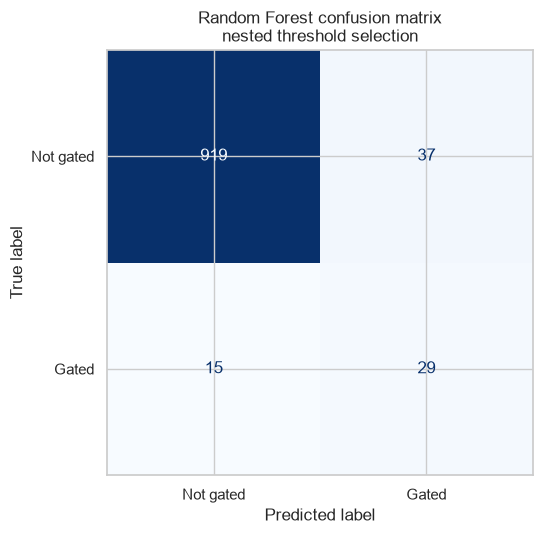


### 6.1 Confusion matrix interpretation

- True negatives: **919**; false positives: **37**; false negatives: **15**; true positives: **29**.
- **Most critical error:** false negatives. They label a restricted model as unrestricted, which can break an automated download or deployment workflow and create avoidable access failures.
- False positives create unnecessary caution or manual review, but they do not incorrectly promise access.
- Each outer fold uses a threshold selected only from its inner training folds. The selected thresholds were [0.3, 0.3, 0.4, 0.2, 0.4], so the confusion matrix evaluates the threshold-selection procedure without reusing validation outcomes.


In [19]:
cm = confusion_matrix(y_clf, selected_pred)
tn, fp, fn, tp = cm.ravel()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(cm, display_labels=["Not gated", "Gated"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"{preferred_clf_name} confusion matrix\nnested threshold selection")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "08_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

display(Markdown(f'''
### 6.1 Confusion matrix interpretation

- True negatives: **{tn}**; false positives: **{fp}**; false negatives: **{fn}**; true positives: **{tp}**.
- **Most critical error:** false negatives. They label a restricted model as unrestricted, which can break an automated download or deployment workflow and create avoidable access failures.
- False positives create unnecessary caution or manual review, but they do not incorrectly promise access.
- Each outer fold uses a threshold selected only from its inner training folds. The selected thresholds were {outer_thresholds['Inner-selected threshold'].tolist()}, so the confusion matrix evaluates the threshold-selection procedure without reusing validation outcomes.
'''))


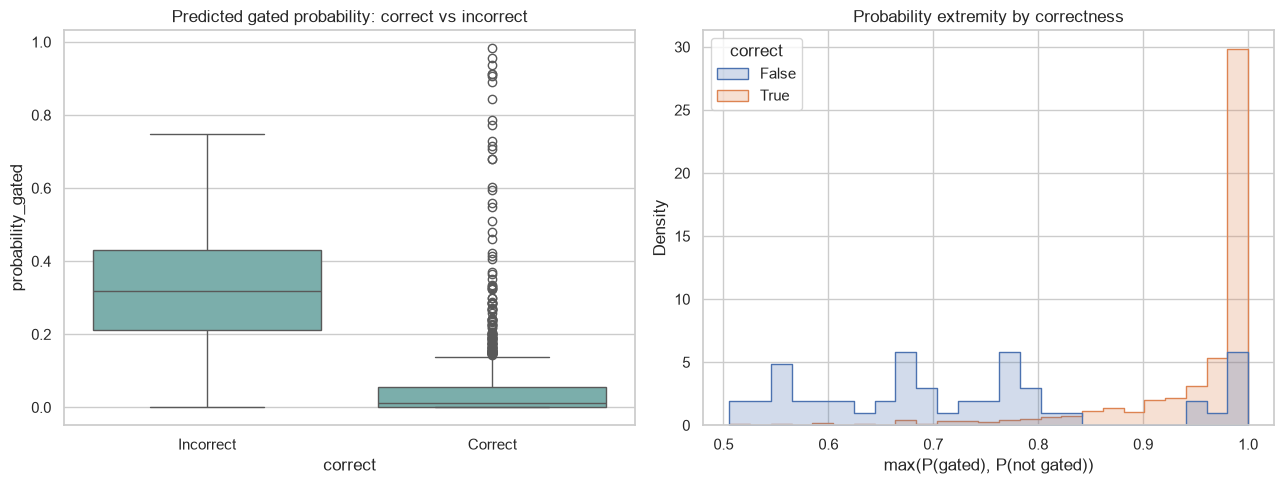

,id,pipeline_tag,library_name,actual,predicted,probability_gated,threshold_used,probability_confidence
155419,CohereLabs/cohere-transcribe-03-2026,automatic-speech-recognition,transformers,1,0,0.0000,0.4000,1.0000
155842,nvidia/Cosmos-Reason2-2B,image-text-to-text,cosmos,1,0,0.0000,0.4000,1.0000
155820,google/medgemma-1.5-4b-it,image-text-to-text,transformers,1,0,0.0150,0.4000,0.9850
155747,speakleash/Bielik-11B-v3.0-Instruct,text-generation,transformers,1,0,0.0174,0.4000,0.9826
155709,littlejohn-ai/bge-m3-spa-law-qa,sentence-similarity,sentence-transformers,1,0,0.0192,0.3000,0.9808
155851,meta-llama/Llama-3.1-405B-FP8,text-generation,transformers,1,0,0.0194,0.3000,0.9806
155090,meta-llama/Prompt-Guard-86M,text-classification,transformers,1,0,0.0201,0.4000,0.9799
155933,black-forest-labs/FLUX.1-Fill-dev,unknown,diffusers,1,0,0.0504,0.4000,0.9496
155825,google/gemma-3n-E2B-it,image-text-to-text,transformers,1,0,0.0509,0.3000,0.9491
155610,briaai/RMBG-2.0,image-segmentation,transformers,1,0,0.1688,0.3000,0.8312


In [20]:
clf_errors = modeling[["id", "author", "pipeline_tag", "library_name", "downloads"] + clf_numeric].copy()
clf_errors["actual"] = y_clf.to_numpy()
clf_errors["probability_gated"] = nested_threshold_prob
clf_errors["threshold_used"] = nested_threshold_used
clf_errors["predicted"] = selected_pred
clf_errors["correct"] = clf_errors["actual"].eq(clf_errors["predicted"])
clf_errors["probability_confidence"] = np.maximum(
    clf_errors["probability_gated"], 1 - clf_errors["probability_gated"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=clf_errors, x="correct", y="probability_gated", ax=axes[0], color="#72B7B2")
axes[0].set_title("Predicted gated probability: correct vs incorrect")
axes[0].set_xticks([0, 1], labels=["Incorrect", "Correct"])
sns.histplot(
    data=clf_errors,
    x="probability_confidence",
    hue="correct",
    bins=25,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[1],
)
axes[1].set_title("Probability extremity by correctness")
axes[1].set_xlabel("max(P(gated), P(not gated))")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "09_probability_correctness.png", dpi=180, bbox_inches="tight")
plt.show()

high_confidence_errors = clf_errors.loc[
    (~clf_errors["correct"]) & (clf_errors["probability_confidence"] >= .8)
].sort_values("probability_confidence", ascending=False)
high_confidence_errors[[
    "id", "pipeline_tag", "library_name", "actual", "predicted",
    "probability_gated", "threshold_used", "probability_confidence",
]]


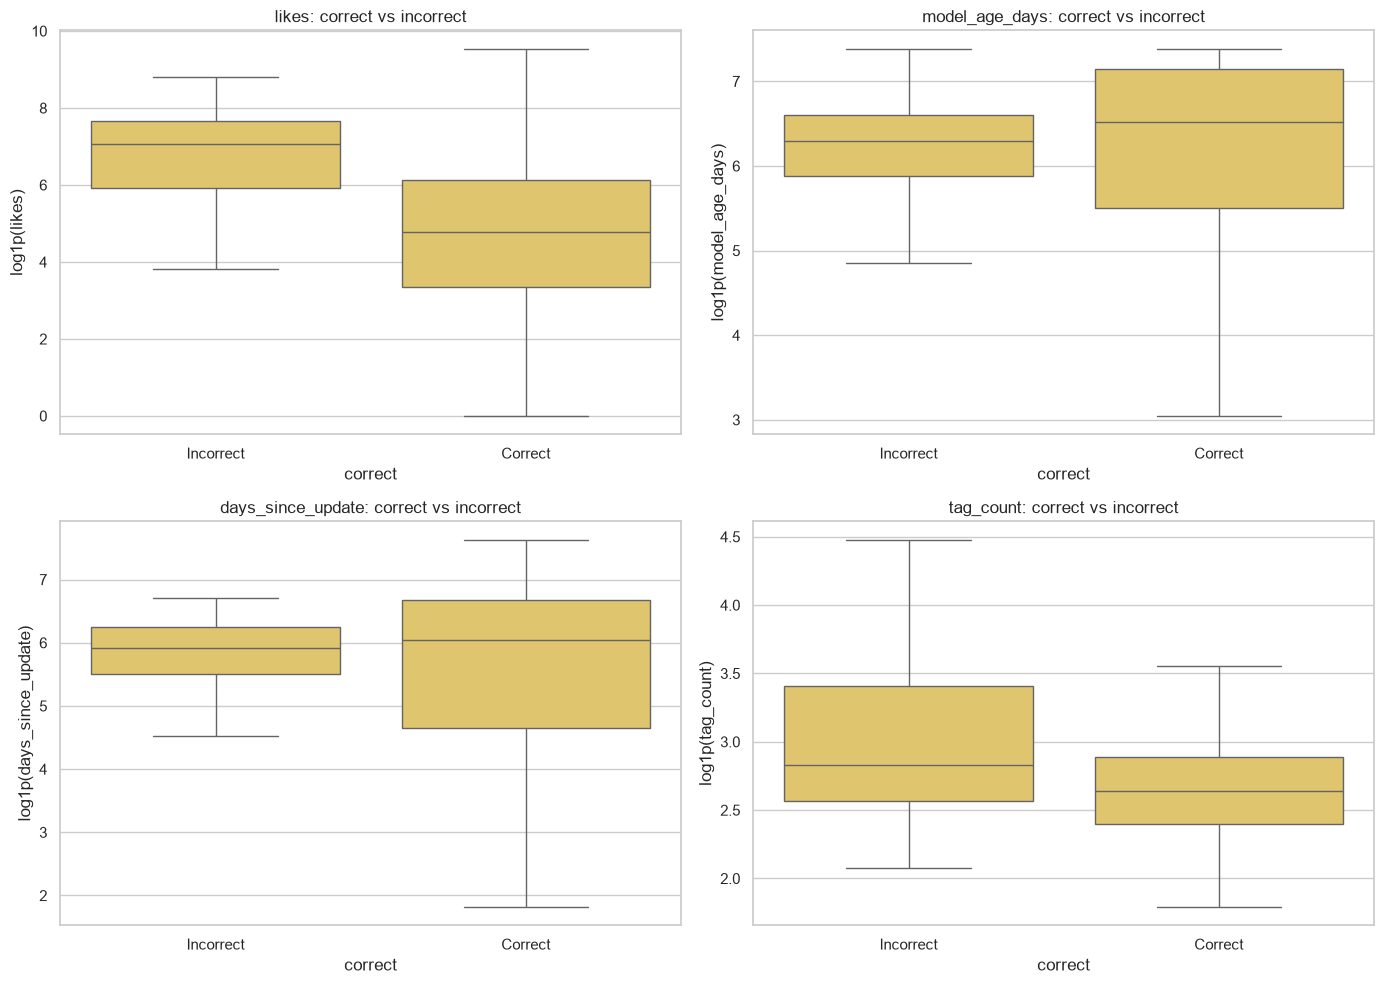

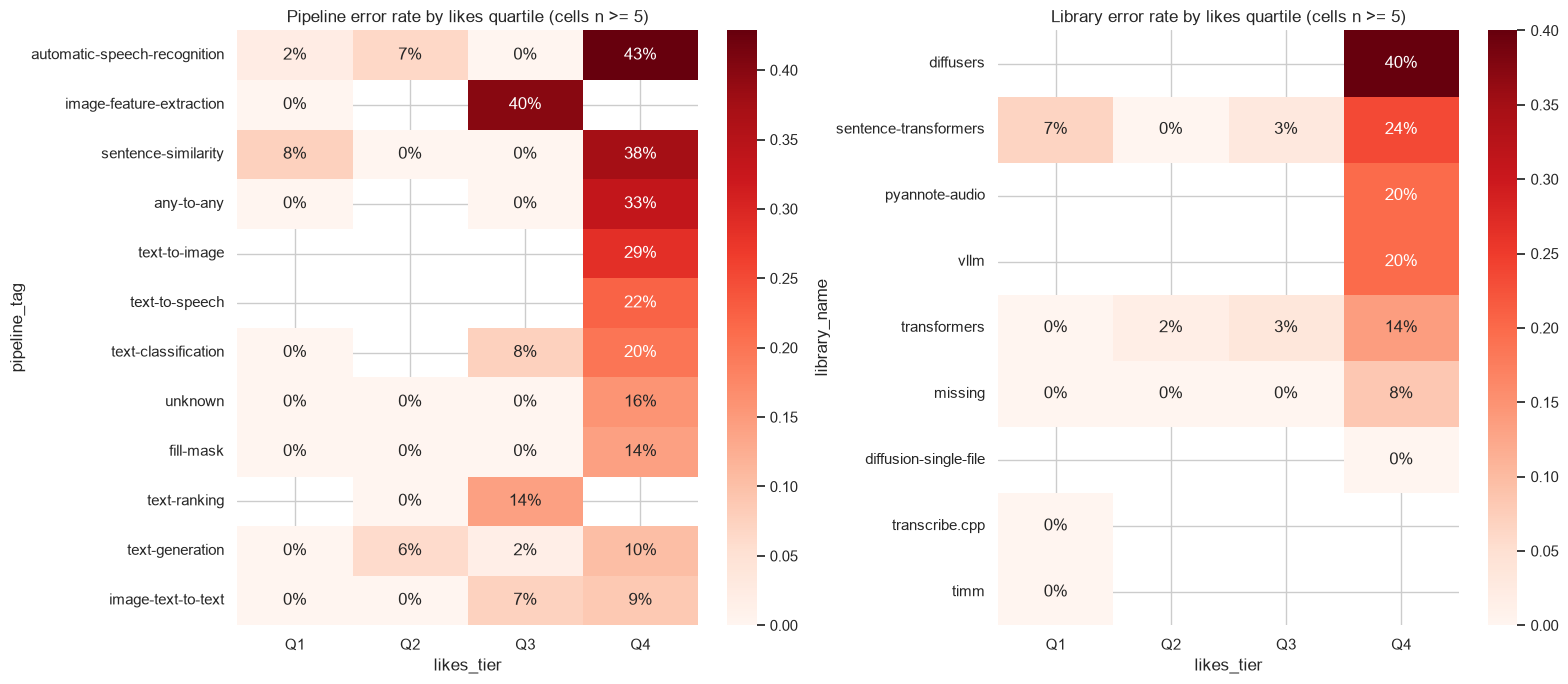

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feature in zip(axes.ravel(), clf_numeric):
    plot_column = f"log1p_{feature}"
    plot_frame = clf_errors.assign(**{plot_column: np.log1p(clf_errors[feature].clip(lower=0))})
    sns.boxplot(data=plot_frame, x="correct", y=plot_column, showfliers=False, ax=ax, color="#F2CF5B")
    ax.set_xticks([0, 1], labels=["Incorrect", "Correct"])
    ax.set_ylabel(f"log1p({feature})")
    ax.set_title(f"{feature}: correct vs incorrect")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "10_classification_error_features.png", dpi=180, bbox_inches="tight")
plt.show()

region_base = clf_errors.assign(
    likes_tier=pd.qcut(clf_errors["likes"], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")
)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, category, title in [
    (axes[0], "pipeline_tag", "Pipeline"),
    (axes[1], "library_name", "Library"),
]:
    region_error = (
        region_base.groupby([category, "likes_tier"], observed=True)
        .agg(models=("id", "size"), error_rate=("correct", lambda s: 1 - s.mean()))
        .reset_index()
    )
    region_error = region_error.loc[region_error["models"].ge(5)]
    pivot_error = region_error.pivot(index=category, columns="likes_tier", values="error_rate")
    pivot_error = pivot_error.loc[pivot_error.max(axis=1).sort_values(ascending=False).head(12).index]
    vmax = max(.25, np.nanmax(pivot_error.to_numpy()))
    sns.heatmap(pivot_error, annot=True, fmt=".0%", cmap="Reds", vmin=0, vmax=vmax, ax=ax)
    ax.set_title(f"{title} error rate by likes quartile (cells n >= 5)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "11_classification_error_regions.png", dpi=180, bbox_inches="tight")
plt.show()


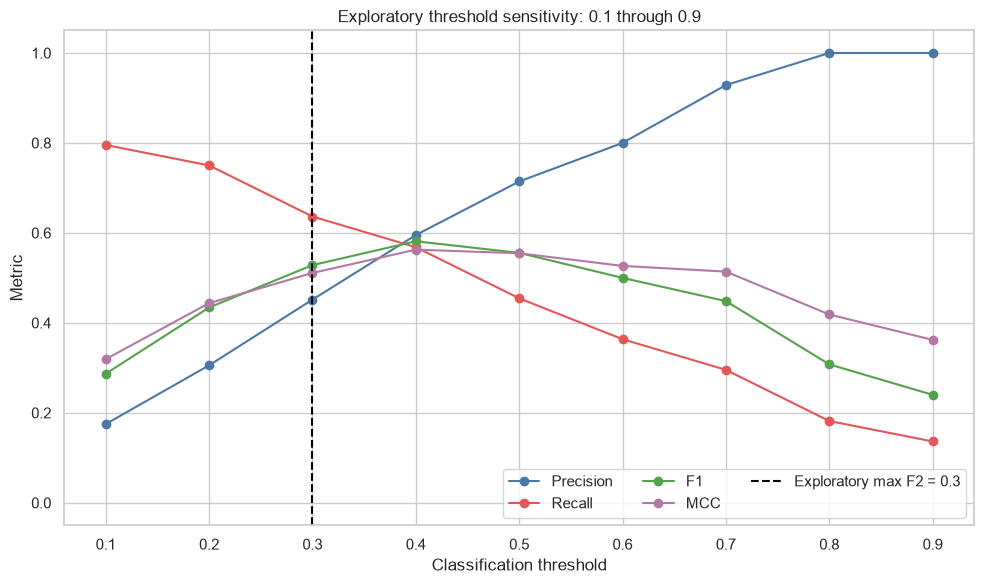

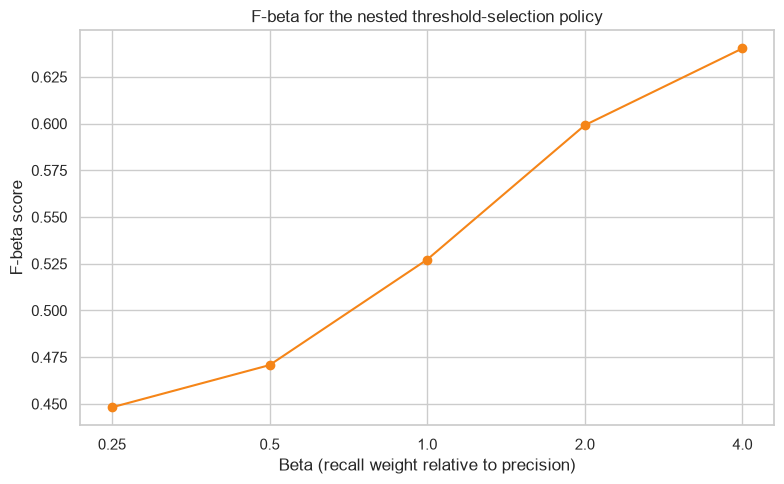

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
for metric, color in [("Precision", "#4C78A8"), ("Recall", "#E45756"), ("F1", "#54A24B"), ("MCC", "#B279A2")]:
    ax.plot(threshold_metrics["Threshold"], threshold_metrics[metric], marker="o", label=metric, color=color)
ax.axvline(
    exploratory_threshold,
    color="black",
    linestyle="--",
    label=f"Exploratory max F2 = {exploratory_threshold:.1f}",
)
ax.set_ylim(-.05, 1.05)
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Metric")
ax.set_title("Exploratory threshold sensitivity: 0.1 through 0.9")
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "12_threshold_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

betas = np.array([.25, .5, 1, 2, 4])
fbeta_values = [fbeta_score(y_clf, selected_pred, beta=float(beta), zero_division=0) for beta in betas]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(betas, fbeta_values, marker="o", color="#F58518")
ax.set_xscale("log", base=2)
ax.set_xticks(betas, labels=[str(x) for x in betas])
ax.set_xlabel("Beta (recall weight relative to precision)")
ax.set_ylabel("F-beta score")
ax.set_title("F-beta for the nested threshold-selection policy")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "13_fbeta_by_beta.png", dpi=180, bbox_inches="tight")
plt.show()


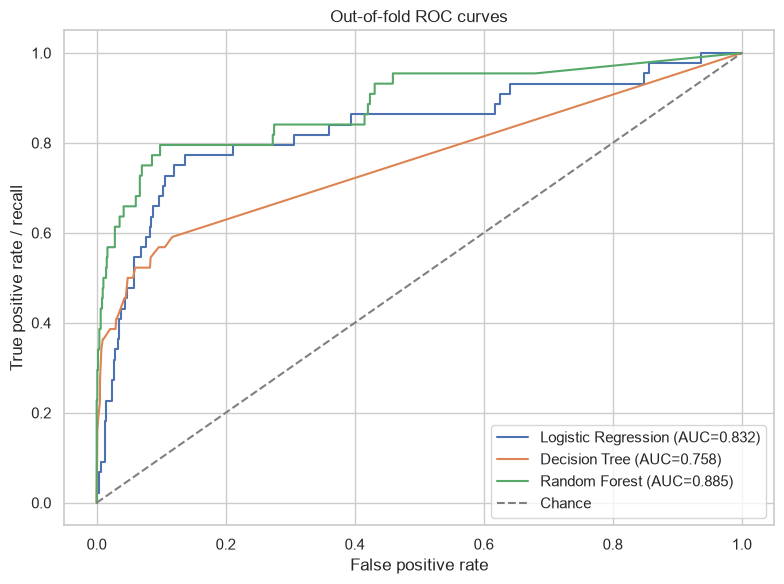

,Model,AUC
2,Random Forest,0.8849
0,Logistic Regression,0.8320
1,Decision Tree,0.7577


In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
roc_rows = []
for name, prob in clf_probabilities.items():
    fpr, tpr, _ = roc_curve(y_clf, prob)
    auc = roc_auc_score(y_clf, prob)
    roc_rows.append({"Model": name, "AUC": auc})
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate / recall")
ax.set_title("Out-of-fold ROC curves")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "14_roc_curve.png", dpi=180, bbox_inches="tight")
plt.show()
pd.DataFrame(roc_rows).sort_values("AUC", ascending=False)


In [24]:
step_metrics = ["Precision", "Recall", "F1", "MCC"]
threshold_metrics["Max adjacent change"] = threshold_metrics[step_metrics].diff().abs().max(axis=1)
interval_changes = threshold_metrics.dropna(subset=["Max adjacent change"]).copy()
interval_changes["Interval"] = interval_changes["Threshold"].map(
    lambda value: f"{value - 0.1:.1f}-{value:.1f}"
)
stable_intervals = interval_changes.nsmallest(2, "Max adjacent change")["Interval"].tolist()
unstable_intervals = interval_changes.nlargest(2, "Max adjacent change")["Interval"].tolist()

display(Markdown(f'''
### 6.2-6.4 Classification error interpretation

- **Probability separation:** correct predictions generally have more decisive probabilities, but overlapping distributions show that probability alone cannot remove all errors.
- **High-confidence-error candidates:** {len(high_confidence_errors)} incorrect predictions have an extreme class probability of at least 0.80. Random Forest probabilities are not calibrated, so these are candidates for investigation rather than literal 80% guarantees.
- **Failure regions:** the heatmaps compare pipeline and library regions across likes quartiles. Cells are shown only when they contain at least five models, and the sample size restriction is stated to limit over-interpretation.
- **Threshold trade-off:** lowering a fixed threshold raises recall and false positives; raising it improves precision but misses more gated models. The global F2 optimum of {exploratory_threshold:.1f} is descriptive only. Threshold-specific evaluation uses inner selection within each outer fold.
- **Stable regions:** by the smallest maximum adjacent change across precision, recall, F1, and MCC, intervals {stable_intervals} are comparatively stable in metric movement. Stability does not imply usefulness: the high-threshold interval has low recall and misses most gated models. The largest joint metric changes occur in intervals {unstable_intervals}.
- **F-beta:** beta below 1 emphasizes precision, beta above 1 emphasizes recall. The plotted curve evaluates the nested threshold-selection policy rather than a threshold optimized and scored on the same rows.
- **ROC-AUC:** the preferred model's out-of-fold AUC is {roc_auc_score(y_clf, preferred_clf_prob):.3f}. AUC measures ranking across all thresholds, while average precision is more sensitive to the rare gated class.
'''))


### 6.2-6.4 Classification error interpretation

- **Probability separation:** correct predictions generally have more decisive probabilities, but overlapping distributions show that probability alone cannot remove all errors.
- **High-confidence-error candidates:** 11 incorrect predictions have an extreme class probability of at least 0.80. Random Forest probabilities are not calibrated, so these are candidates for investigation rather than literal 80% guarantees.
- **Failure regions:** the heatmaps compare pipeline and library regions across likes quartiles. Cells are shown only when they contain at least five models, and the sample size restriction is stated to limit over-interpretation.
- **Threshold trade-off:** lowering a fixed threshold raises recall and false positives; raising it improves precision but misses more gated models. The global F2 optimum of 0.3 is descriptive only. Threshold-specific evaluation uses inner selection within each outer fold.
- **Stable regions:** by the smallest maximum adjacent change across precision, recall, F1, and MCC, intervals ['0.8-0.9', '0.5-0.6'] are comparatively stable in metric movement. Stability does not imply usefulness: the high-threshold interval has low recall and misses most gated models. The largest joint metric changes occur in intervals ['0.1-0.2', '0.2-0.3'].
- **F-beta:** beta below 1 emphasizes precision, beta above 1 emphasizes recall. The plotted curve evaluates the nested threshold-selection policy rather than a threshold optimized and scored on the same rows.
- **ROC-AUC:** the preferred model's out-of-fold AUC is 0.885. AUC measures ranking across all thresholds, while average precision is more sensitive to the rare gated class.


## 7. Integrated discussion

### Strengths and limitations

- Linear and logistic models provide transparent baselines but cannot naturally capture complex interactions or abrupt thresholds.
- Trees represent nonlinear regions, but a single tree has high variance. Random Forests improve stability through averaging and are the strongest general-purpose candidates here.
- KNN is flexible but sensitive to scaling, local sparsity, and mixed one-hot/numeric geometry.
- The sample contains only trending models, not the complete Hugging Face Hub. Results should not be generalized to unpopular or newly uploaded models without validation.
- Gated status is ordinarily available as authoritative metadata. The classifier is a benchmark for error analysis, not a recommended replacement for reading that field. Downloads are excluded because gating may affect them and create a downstream target proxy.

### Key failure modes

1. **Exceptional popularity:** blockbuster models create heavy-tailed regression residuals.
2. **Omitted causes:** traffic from external products, APIs, media events, and deployment partnerships is not present.
3. **Sparse subpopulations:** rare pipelines and libraries provide too few examples for stable local rules.
4. **Metadata quality:** `library_name` is missing for some models and `license` is entirely missing.
5. **Class imbalance:** gated models are rare, so the classifier can appear accurate while missing the cases that matter.
6. **Probability interpretation:** Random Forest probabilities are not calibrated and should not be read as literal confidence guarantees.

### Concrete improvements

- Add longitudinal growth features from earlier snapshots without leaking future information.
- Retrieve missing library and license metadata from model cards or the Hugging Face API.
- Add organization, model-size, deployment, and external-traffic indicators.
- Tune hyperparameters through nested cross-validation rather than using a single fixed configuration.
- Calibrate classification probabilities and set the threshold from an explicit business cost matrix.
- Collect more gated examples and evaluate performance by task, library, and organization before deployment.


## 8. Final reflection

1. **Where does the model fail most?** Regression fails most on extremely popular models and in pipeline sectors with elevated top-5% error rates. Classification fails in underrepresented pipeline/library and popularity regions.
2. **Are failures due to data, model, or formulation?** All three. Missing and omitted variables are data limitations; linearity and local sparsity are model limitations; the trending-only sample and the artificial need to predict an ordinarily available gated-status field are formulation limitations.
3. **What improvements would you propose?** Add leakage-safe time features and richer metadata, repair missing fields from authoritative sources, use nested tuning and probability calibration, and select thresholds from explicit false-positive/false-negative costs.
4. **What insights did you gain?** Aggregate metrics hide structured failures. Out-of-fold error analysis shows that a model can rank well while remaining unreliable for rare classes or exceptional observations. Threshold selection must be evaluated without reusing the same outcomes, and probability extremes are not calibrated guarantees.


In [25]:
# Generate the concise Markdown report from the verified notebook results.
nested_precision = precision_score(y_clf, selected_pred, zero_division=0)
nested_recall = recall_score(y_clf, selected_pred, zero_division=0)
nested_f1 = f1_score(y_clf, selected_pred, zero_division=0)
nested_f2 = fbeta_score(y_clf, selected_pred, beta=2, zero_division=0)
nested_mcc = matthews_corrcoef(y_clf, selected_pred)
report = f'''# Homework 2 - Written Answers

**Student:** Tedi Revelis<br>
**Student ID:** 313261919<br>
**Dataset:** Hugging Face Models Trending

## Method and cross-validation

The complete dataset contains {len(df):,} rows and {df.shape[1]} original columns. Modeling uses the latest snapshot ({len(modeling):,} unique models) so repeated daily observations do not violate independence. I selected 5-fold cross-validation: each regression fold contains about 200 validation models, and stratification leaves approximately 8-9 gated examples in each classification validation fold. Preprocessing is fitted inside every fold, and every reported prediction is out-of-fold. Fixed model settings were chosen before evaluation rather than tuned on these scores.

## Regression model comparison

The required Linear Regression, Decision Tree, and Random Forest models use the same feature set. KNN is included for bonus comparison. All models learn a log1p-transformed target and return predictions in original download units.

{markdown_table(reg_metrics)}

The preferred model is **{preferred_reg_name}** with MAE {best_reg['MAE']:,.0f}, RMSE {best_reg['RMSE']:,.0f}, and R2 {best_reg['R2']:.3f}. Nonlinear models can capture thresholds and interactions; the linear model is easier to interpret but has higher structural bias. A single tree has higher variance, while Random Forest reduces variance through averaging. KNN is sensitive to sparse local neighborhoods.

## Regression error analysis

- Mean residual: {error_stats['Residual mean']:,.0f}
- Residual standard deviation: {error_stats['Residual standard deviation']:,.0f}
- MAE: {error_stats['MAE']:,.0f}
- Skewness: {error_stats['Residual skewness']:.3f}
- Excess kurtosis: {error_stats['Residual excess kurtosis']:.3f}
- Top-5% absolute-error cutoff: {extreme_cutoff:,.0f} ({len(extreme)} observations)

Residuals are not homoskedastic: the cloud widens with predicted popularity, and exceptional blockbuster models are systematically under-predicted. Among pipeline sectors with at least 10 observations, `{highest_sector}` has the largest observed rate of top-5% errors ({highest_sector_count}/{highest_sector_models}, {highest_sector_rate:.1%}). All 50 extreme observations are analyzed individually in the notebook and exported to `reports/EXTREME_ERROR_ANALYSIS.csv` with error direction, scale, local sample size, and likely-source notes.

## Classification model comparison

{markdown_table(clf_metrics)}

The preferred classifier is **{preferred_clf_name}**, with out-of-fold ROC-AUC {best_clf['ROC-AUC']:.3f} and average precision {best_clf['Average Precision']:.3f}. Average precision is emphasized because only {int(y_clf.sum())} of {len(y_clf)} models are gated. Downloads are excluded from the predictors because gating may affect download activity; the task is an error-analysis benchmark rather than a replacement for authoritative metadata.

## Confusion matrix and error implications

Nested threshold selection gives TN={tn}, FP={fp}, FN={fn}, TP={tp}. Each outer fold applies a threshold selected only from inner training folds: {outer_thresholds['Inner-selected threshold'].tolist()}. False negatives are most critical because they identify a restricted model as unrestricted, potentially breaking automated access or deployment workflows. False positives create extra review but do not incorrectly promise access.

## Probability, feature, and threshold analysis

There are {len(high_confidence_errors)} incorrect predictions with extreme class probability of at least 0.80. Because the probabilities are not calibrated, these are investigation candidates rather than literal confidence guarantees. Error rates vary by pipeline, library, and likes tier, especially in sparse subpopulations.

{markdown_table(threshold_metrics.drop(columns=['Max adjacent change']))}

The fixed-threshold table is exploratory. Its global F2 optimum is {exploratory_threshold:.1f}, but the unbiased threshold-policy estimate comes from nested selection. That policy has precision {nested_precision:.3f}, recall {nested_recall:.3f}, F1 {nested_f1:.3f}, F2 {nested_f2:.3f}, and MCC {nested_mcc:.3f}. Comparatively stable adjacent intervals are {stable_intervals}; however, the high-threshold stable interval has low recall and is not operationally attractive. The largest joint metric changes occur in {unstable_intervals}.

## Final reflection

1. Regression fails most on blockbuster models and sectors with elevated top-5% error rates; classification fails in underrepresented pipeline/library and popularity regions.
2. Failures arise from missing or omitted data, model assumptions, and formulation choices, including a trending-only sample and an ordinarily observable classification target.
3. Improvements include leakage-safe longitudinal features, authoritative metadata repair, nested tuning, probability calibration, explicit error costs, and more gated examples.
4. Aggregate scores are insufficient. Error structure, minority-class behavior, fold stability, and leakage-safe threshold evaluation determine whether a model is actually reliable.
'''
(ROOT / "reports" / "OPEN_QUESTIONS.md").write_text(report, encoding="utf-8")
print("Generated reports/OPEN_QUESTIONS.md")
print("Generated reports/EXTREME_ERROR_ANALYSIS.csv")
print(f"Exported {len(list(FIGURE_DIR.glob('*.png')))} figures")

Generated reports/OPEN_QUESTIONS.md
Generated reports/EXTREME_ERROR_ANALYSIS.csv
Exported 14 figures


## Reproducibility

The final code cell regenerates the written numerical summary and confirms the number of exported figures. The dataset checksum, fixed random seed, and fold-specific preprocessing make the analysis reproducible.
